In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
housing = fetch_california_housing()

data=pd.DataFrame(housing.data,columns =housing.feature_names)
data["price"]=housing.target

In [7]:
x=data[['AveRooms']].values
y=data['price'].values

In [8]:
x_train, x_test ,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [9]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(x_train)
X_test_scaled=scaler.transform(x_test)

In [10]:
w=0
b=0

learning_rate=0.01
epochs=1000

n=len(X_train_scaled)

for i in range(epochs):
    y_pred= w* X_train_scaled.flatten()+b
    dw =(1/n)*np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db = (1/n)*np.sum(y_pred-y_train)

    w=w-learning_rate*dw
    b=b-learning_rate*db

    if i%100 ==0:
        cost=(1/(2*n))*np.sum((y_pred-y_train)**2)
        print(f"Epoch {i},cost ={cost:.4f}")

        y_pred_gd = w*X_test_scaled.flatten()+b

Epoch 0,cost =2.8149
Epoch 100,cost =0.9414
Epoch 200,cost =0.6904
Epoch 300,cost =0.6568
Epoch 400,cost =0.6523
Epoch 500,cost =0.6517
Epoch 600,cost =0.6516
Epoch 700,cost =0.6516
Epoch 800,cost =0.6516
Epoch 900,cost =0.6516


In [12]:

        print("Gradient Descent")
        print("----------------")
        print("weight:",w)
        print("Bias:",b)
        print("MSE:",mean_squared_error(y_test,y_pred_gd))
        print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.2923212346292208
R2 Score: 0.013803128574378376


In [26]:
X_train_ne =np.c_[np.ones((len(x_train),1)), x_train]
X_test_ne =np.c_[np.ones((len(x_test),1)), x_test]
theta= np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne= X_test_ne @ theta

print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_gd))



Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013803128574378376


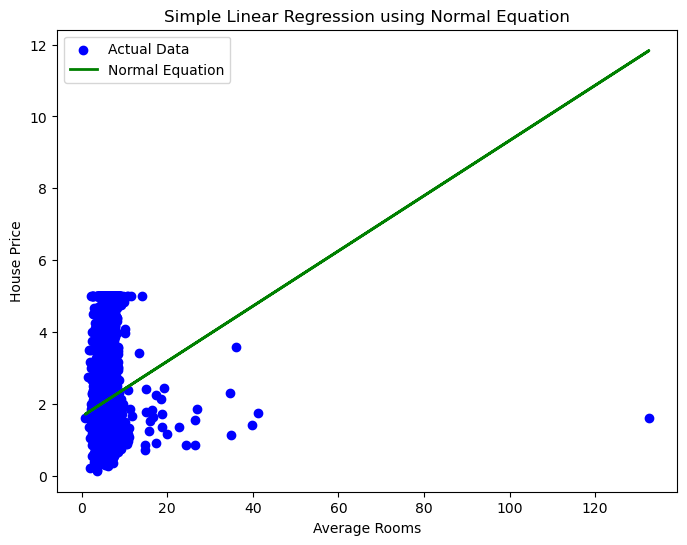

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(x_test, y_test, color='blue', label='Actual Data')
plt.plot(x_test, y_pred_ne, color='green', linewidth=2, label='Normal Equation')

plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Simple Linear Regression using Normal Equation")
plt.legend()

plt.show()

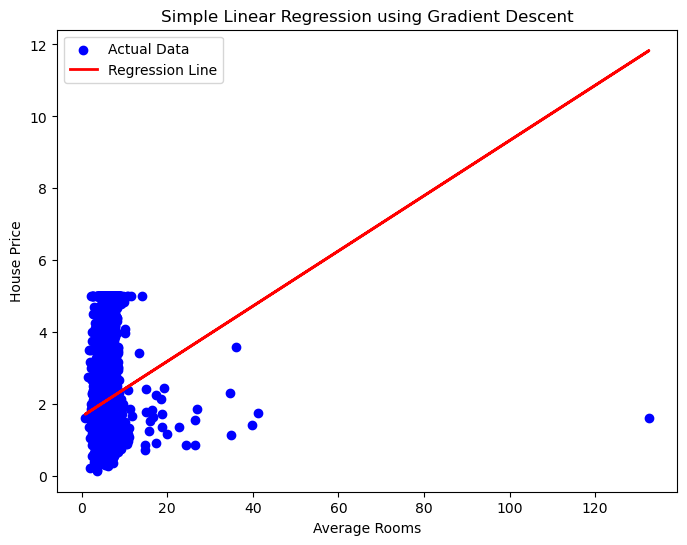

In [28]:
plt.figure(figsize=(8,6))

# Actual data
plt.scatter(x_test, y_test, color='blue', label='Actual Data')

# Predicted line
plt.plot(x_test, y_pred_gd, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Simple Linear Regression using Gradient Descent")
plt.legend()

plt.show()

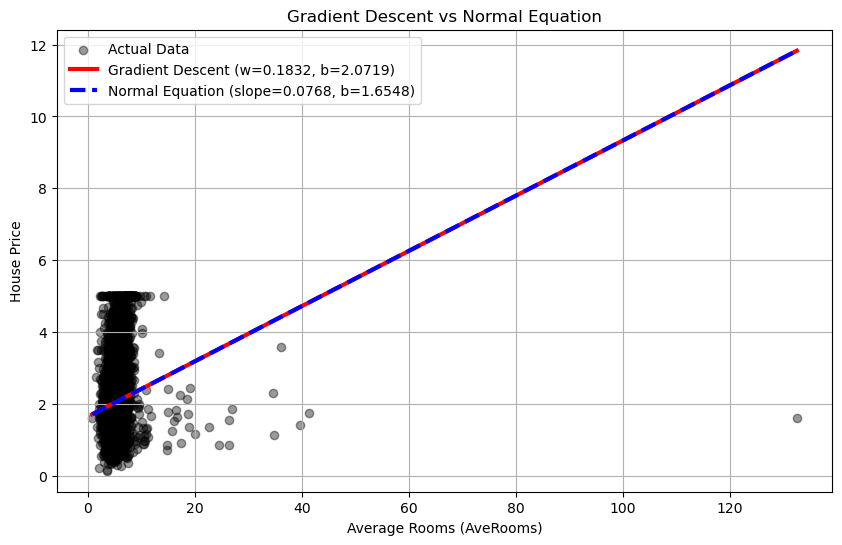

In [31]:
import matplotlib.pyplot as plt
import numpy as np

idx = np.argsort(x_test.flatten())

plt.figure(figsize=(10,6))

# Actual values
plt.scatter(x_test, y_test, color='black', alpha=0.4, label="Actual Data")

# Gradient Descent line
plt.plot(x_test.flatten()[idx], y_pred_gd[idx],
         color='red', linewidth=3,
         label="Gradient Descent (w=0.1832, b=2.0719)")

# Normal Equation line
plt.plot(x_test.flatten()[idx], y_pred_ne[idx],
         color='blue', linestyle='--', linewidth=3,
         label="Normal Equation (slope=0.0768, b=1.6548)")

plt.xlabel("Average Rooms (AveRooms)")
plt.ylabel("House Price")
plt.title("Gradient Descent vs Normal Equation")

plt.legend()
plt.grid(True)

plt.show()